# GTM Funnel Analysis
**Project 2 — Revenue & GTM Analytics**

Analyzes conversion rates and velocity across the full B2B funnel:
Lead → MQL → SQL → Opportunity → Closed-Won

**Key questions:**
1. What are the stage-by-stage conversion rates?
2. Which lead sources drive the highest-quality pipeline?
3. How fast does the funnel move (lead-to-close velocity)?
4. Where does the funnel leak the most by segment?

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from mart_simulator import (
    build_stg_leads, build_stg_opps,
    build_int_gtm_funnel, build_fct_customer_lifecycle
)

pd.set_option('display.float_format', '{:,.1f}'.format)
pd.set_option('display.max_columns', 30)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
leads   = build_stg_leads()
opps    = build_stg_opps()
gtm     = build_int_gtm_funnel()
lifecycle = build_fct_customer_lifecycle()

print(f'Leads:    {len(leads):,} rows')
print(f'Opps:     {len(opps):,} rows')
print(f'Accounts: {len(gtm):,} rows (GTM funnel)')

Leads:    3,200 rows
Opps:     1,800 rows
Accounts: 1,200 rows (GTM funnel)


## 2. Funnel Volume — Stage by Stage

Counts unique accounts at each funnel stage to measure conversion.

In [3]:
# Total accounts in each system
total_accounts  = len(gtm)
with_lead       = gtm['has_lead'].sum()
mql_plus        = (gtm['max_lifecycle_rank'] >= 2).sum()
sql_plus        = (gtm['max_lifecycle_rank'] >= 3).sum()
with_opp        = gtm['has_opportunity'].sum()
with_won        = gtm['has_won_opportunity'].sum()

funnel = pd.DataFrame({
    'Stage': ['All Accounts', 'Has Lead', 'MQL+', 'SQL+', 'Has Opportunity', 'Closed-Won'],
    'Count': [total_accounts, with_lead, mql_plus, sql_plus, with_opp, with_won]
})
funnel['Conv vs Prior'] = funnel['Count'].pct_change().fillna(0)
funnel['Conv vs Top']   = funnel['Count'] / total_accounts

print('=== GTM Funnel Volume ===')
display(funnel.style
    .format({'Count': '{:,}', 'Conv vs Prior': '{:.1%}', 'Conv vs Top': '{:.1%}'})
    .bar(subset=['Count'], color='#4C72B0')
)

=== GTM Funnel Volume ===


,Stage,Count,Conv vs Prior,Conv vs Top
0,All Accounts,"1,200",0.0%,100.0%
1,Has Lead,"1,122",-6.5%,93.5%
2,MQL+,943,-16.0%,78.6%
3,SQL+,651,-31.0%,54.2%
4,Has Opportunity,922,41.6%,76.8%
5,Closed-Won,325,-64.8%,27.1%


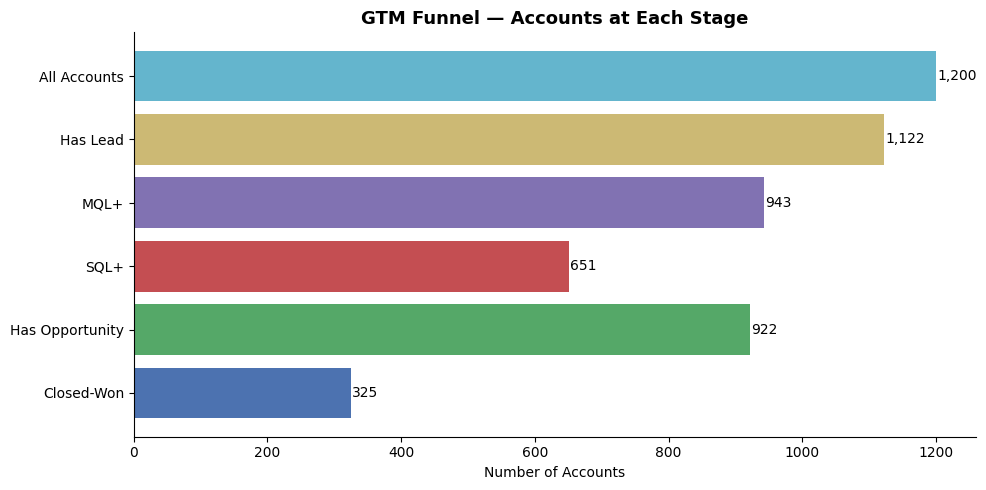


Key finding: 27.1% of all accounts ever reached Closed-Won.
Lead-to-Won conversion: 29.0% of accounts with a lead converted to a win.


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']
bars = ax.barh(funnel['Stage'][::-1], funnel['Count'][::-1], color=colors)

for bar, val in zip(bars, funnel['Count'][::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Number of Accounts')
ax.set_title('GTM Funnel — Accounts at Each Stage', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print(f'\nKey finding: {with_won/total_accounts:.1%} of all accounts ever reached Closed-Won.')
print(f'Lead-to-Won conversion: {with_won/max(with_lead,1):.1%} of accounts with a lead converted to a win.')

## 3. Lead Source Quality

Not all lead sources are equal — we measure quality by downstream conversion, not just volume.

In [5]:
# Lead volume by source
lead_source_vol = (
    leads.groupby('lead_source')
    .agg(
        lead_count=('lead_id', 'nunique'),
        sql_count=('is_sales_qualified', 'sum'),
        unique_accounts=('account_id', 'nunique'),
    )
    .reset_index()
)
lead_source_vol['sql_rate'] = lead_source_vol['sql_count'] / lead_source_vol['lead_count']

# Win rate by primary lead source (at account level)
won_by_source = (
    gtm[gtm['primary_lead_source'].notna()]
    .groupby('primary_lead_source')
    .agg(
        accounts=('account_id', 'nunique'),
        won_accounts=('has_won_opportunity', 'sum'),
        total_won_amount=('total_won_amount', 'sum'),
    )
    .reset_index()
    .rename(columns={'primary_lead_source': 'lead_source'})
)
won_by_source['win_rate'] = won_by_source['won_accounts'] / won_by_source['accounts']
won_by_source['avg_deal_size'] = won_by_source['total_won_amount'] / won_by_source['won_accounts'].replace(0, np.nan)

source_summary = lead_source_vol.merge(won_by_source, on='lead_source', how='left')
source_summary = source_summary.sort_values('total_won_amount', ascending=False)

print('=== Lead Source Performance ===')
display(source_summary[['lead_source','lead_count','sql_rate','win_rate','total_won_amount','avg_deal_size']]
    .style
    .format({
        'lead_count': '{:,}',
        'sql_rate': '{:.1%}',
        'win_rate': '{:.1%}',
        'total_won_amount': '${:,.0f}',
        'avg_deal_size': '${:,.0f}'
    })
    .background_gradient(subset=['win_rate'], cmap='Greens')
    .background_gradient(subset=['total_won_amount'], cmap='Blues')
)

=== Lead Source Performance ===


,lead_source,lead_count,sql_rate,win_rate,total_won_amount,avg_deal_size
1,Organic,704,30.4%,29.6%,"$3,588,263","$33,535"
3,Paid Search,570,30.4%,27.2%,"$2,217,782","$48,213"
2,Outbound,447,30.4%,25.4%,"$1,789,702","$38,907"
0,Events,287,25.4%,23.9%,"$1,725,631","$40,131"
5,Partner,385,31.4%,25.0%,"$734,707","$38,669"
4,Paid Social,442,31.2%,28.3%,"$677,873","$24,210"
6,Referral,365,27.1%,25.0%,"$293,004","$20,929"


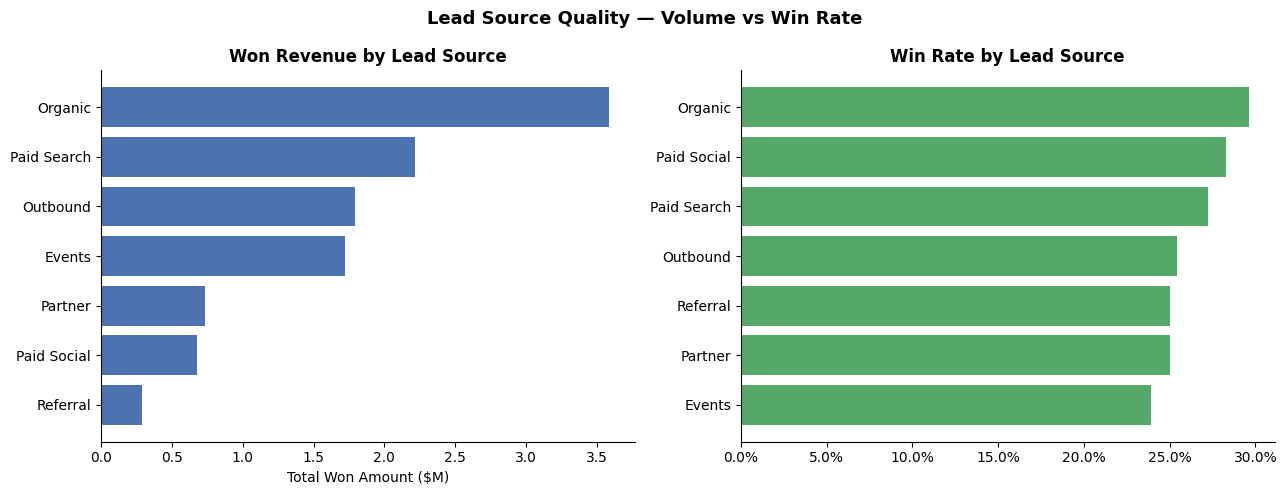

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: won amount by source
s = source_summary.sort_values('total_won_amount', ascending=True).tail(8)
axes[0].barh(s['lead_source'], s['total_won_amount'] / 1e6, color='#4C72B0')
axes[0].set_xlabel('Total Won Amount ($M)')
axes[0].set_title('Won Revenue by Lead Source', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: win rate by source
s2 = source_summary.sort_values('win_rate', ascending=True).tail(8)
axes[1].barh(s2['lead_source'], s2['win_rate'], color='#55A868')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_title('Win Rate by Lead Source', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Lead Source Quality — Volume vs Win Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Funnel Conversion by Segment

Enterprise deals require more nurturing but close at higher values. Does that show in the data?

In [7]:
seg_funnel = (
    gtm.groupby('segment')
    .agg(
        accounts=('account_id', 'nunique'),
        has_lead=('has_lead', 'sum'),
        has_opp=('has_opportunity', 'sum'),
        has_won=('has_won_opportunity', 'sum'),
        total_won=('total_won_amount', 'sum'),
    )
    .reset_index()
)
seg_funnel['lead_rate']   = seg_funnel['has_lead'] / seg_funnel['accounts']
seg_funnel['opp_rate']    = seg_funnel['has_opp']  / seg_funnel['accounts']
seg_funnel['win_rate']    = seg_funnel['has_won']  / seg_funnel['accounts']
seg_funnel['avg_deal']    = seg_funnel['total_won'] / seg_funnel['has_won'].replace(0, np.nan)

display(seg_funnel.style
    .format({
        'accounts': '{:,}',
        'lead_rate': '{:.1%}',
        'opp_rate': '{:.1%}',
        'win_rate': '{:.1%}',
        'total_won': '${:,.0f}',
        'avg_deal': '${:,.0f}'
    })
    .background_gradient(subset=['win_rate'], cmap='Greens')
)

,segment,accounts,has_lead,has_opp,has_won,total_won,lead_rate,opp_rate,win_rate,avg_deal
0,Enterprise,220,208,170,66,"$5,533,522",94.5%,77.3%,30.0%,"$83,841"
1,Mid-Market,400,371,319,116,"$4,085,744",92.8%,79.8%,29.0%,"$35,222"
2,SMB,580,543,433,143,"$2,217,148",93.6%,74.7%,24.7%,"$15,505"


## 5. Sales Velocity

How long does each stage of the funnel take? Measured only on accounts that have progressed through each stage.

In [8]:
l2o = lifecycle['lead_to_opp_days'].dropna()
l2c = lifecycle['lead_to_close_days'].dropna()
opp_close_delta = (lifecycle['lead_to_close_days'] - lifecycle['lead_to_opp_days']).dropna()

print('=== Sales Velocity (days) ===')
vel_summary = pd.DataFrame({
    'Stage Transition': ['Lead → Opportunity', 'Opportunity → Close', 'Lead → Close (Full Cycle)'],
    'Median (days)': [
        l2o.median(),
        opp_close_delta.median(),
        l2c.median()
    ],
    'P25': [l2o.quantile(0.25), opp_close_delta.quantile(0.25), l2c.quantile(0.25)],
    'P75': [l2o.quantile(0.75), opp_close_delta.quantile(0.75), l2c.quantile(0.75)],
    'N accounts': [len(l2o), len(opp_close_delta), len(l2c)]
})
display(vel_summary.style.format({
    'Median (days)': '{:.0f}', 'P25': '{:.0f}', 'P75': '{:.0f}', 'N accounts': '{:,}'
}))

=== Sales Velocity (days) ===


,Stage Transition,Median (days),P25,P75,N accounts
0,Lead → Opportunity,24,-146,200,863
1,Opportunity → Close,117,66,204,303
2,Lead → Close (Full Cycle),166,-46,342,303


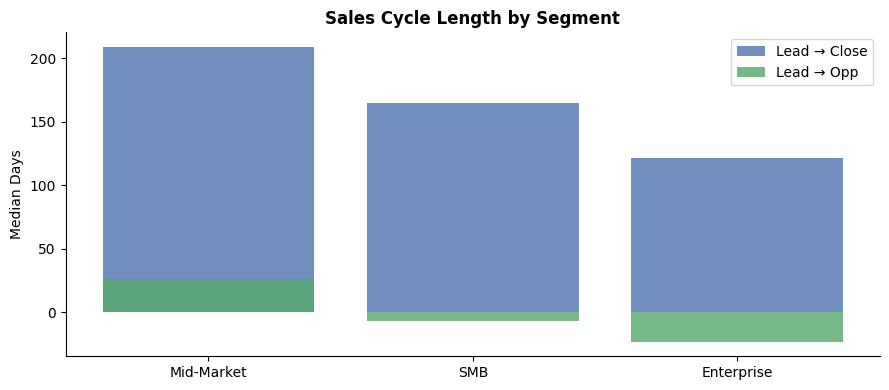


Enterprise typically has longer cycles — confirm if this pattern holds.


In [9]:
# Velocity by segment
lc = lifecycle[['account_id','segment','lead_to_close_days','lead_to_opp_days']].dropna(subset=['lead_to_close_days'])

seg_velocity = lc.groupby('segment').agg(
    median_lead_to_close=('lead_to_close_days', 'median'),
    median_lead_to_opp=('lead_to_opp_days', 'median'),
    count=('account_id', 'nunique')
).reset_index().sort_values('median_lead_to_close', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(seg_velocity))
ax.bar(x, seg_velocity['median_lead_to_close'], label='Lead → Close', color='#4C72B0', alpha=0.8)
ax.bar(x, seg_velocity['median_lead_to_opp'], label='Lead → Opp', color='#55A868', alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(seg_velocity['segment'])
ax.set_ylabel('Median Days')
ax.set_title('Sales Cycle Length by Segment', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nEnterprise typically has longer cycles — confirm if this pattern holds.')

## 6. Unmatched Leads & Orphan Opportunities

Data quality issues surfaced in exploration — how large is the impact?

In [10]:
unmatched_leads = leads[~leads['has_account']]
orphan_opps     = opps[opps['is_orphan']]

print(f'Unmatched leads (no account_id):  {len(unmatched_leads):,} ({len(unmatched_leads)/len(leads):.1%} of all leads)')
print(f'Orphan opportunities:             {len(orphan_opps):,} ({len(orphan_opps)/len(opps):.1%} of all opps)')
print(f'Orphan opp pipeline value:        ${orphan_opps["amount"].sum():,.0f}')

print('\nUnmatched leads by source:')
display(unmatched_leads['lead_source'].value_counts().rename('count').reset_index())

print('\nOrphan opportunities by stage:')
display(orphan_opps['opportunity_stage'].value_counts().rename('count').reset_index())

Unmatched leads (no account_id):  12 (0.4% of all leads)
Orphan opportunities:             9 (0.5% of all opps)
Orphan opp pipeline value:        $68,389

Unmatched leads by source:


,lead_source,count
0,Events,3
1,Paid Search,3
2,Outbound,3
3,Referral,1
4,Paid Social,1
5,Partner,1



Orphan opportunities by stage:


,opportunity_stage,count
0,Closed-Won,3
1,Prospecting,2
2,Closed-Lost,1
3,Proposal,1
4,Negotiation,1
5,Qualification,1


## 7. Summary — Key Findings

In [11]:
# Top-line funnel summary
lead_to_opp_rate = gtm['has_opportunity'].sum() / gtm['has_lead'].sum()
opp_win_rate     = opps[~opps['is_orphan']]['is_won'].sum() / max(opps[~opps['is_orphan']]['is_open'].sum() + opps[~opps['is_orphan']]['is_won'].sum() + opps[~opps['is_orphan']]['is_lost'].sum(), 1)
won_revenue      = gtm['total_won_amount'].sum()

print('=' * 55)
print('  GTM FUNNEL — KEY FINDINGS')
print('=' * 55)
print(f'  Total accounts in CRM:          {total_accounts:,}')
print(f'  Accounts with ≥1 lead:          {with_lead:,} ({with_lead/total_accounts:.0%})')
print(f'  Accounts with ≥1 opportunity:   {with_opp:,} ({with_opp/total_accounts:.0%})')
print(f'  Accounts with ≥1 Closed-Won:    {with_won:,} ({with_won/total_accounts:.0%})')
print(f'  Lead → Opp conversion:          {lead_to_opp_rate:.1%}')
print(f'  Total won pipeline:             ${won_revenue:,.0f}')
print(f'  Unmatched leads (DQ):           {len(unmatched_leads):,}')
print(f'  Orphan opportunities (DQ):      {len(orphan_opps):,}')
print('=' * 55)
print('\ndbt models: int_gtm_funnel → fct_pipeline, fct_customer_lifecycle')

  GTM FUNNEL — KEY FINDINGS
  Total accounts in CRM:          1,200
  Accounts with ≥1 lead:          1,122 (94%)
  Accounts with ≥1 opportunity:   922 (77%)
  Accounts with ≥1 Closed-Won:    325 (27%)
  Lead → Opp conversion:          82.2%
  Total won pipeline:             $11,836,415
  Unmatched leads (DQ):           12
  Orphan opportunities (DQ):      9

dbt models: int_gtm_funnel → fct_pipeline, fct_customer_lifecycle
